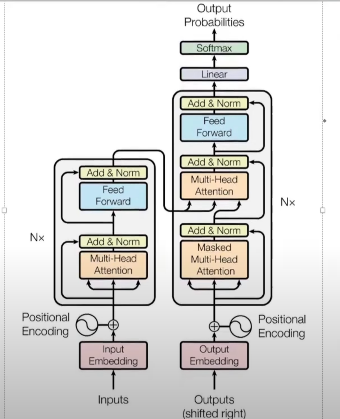

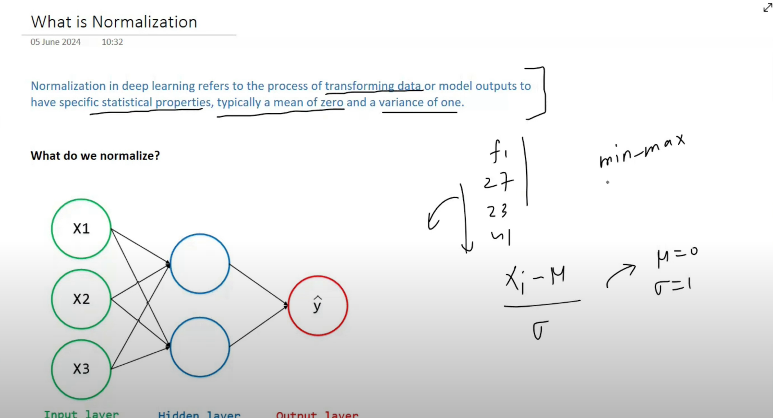

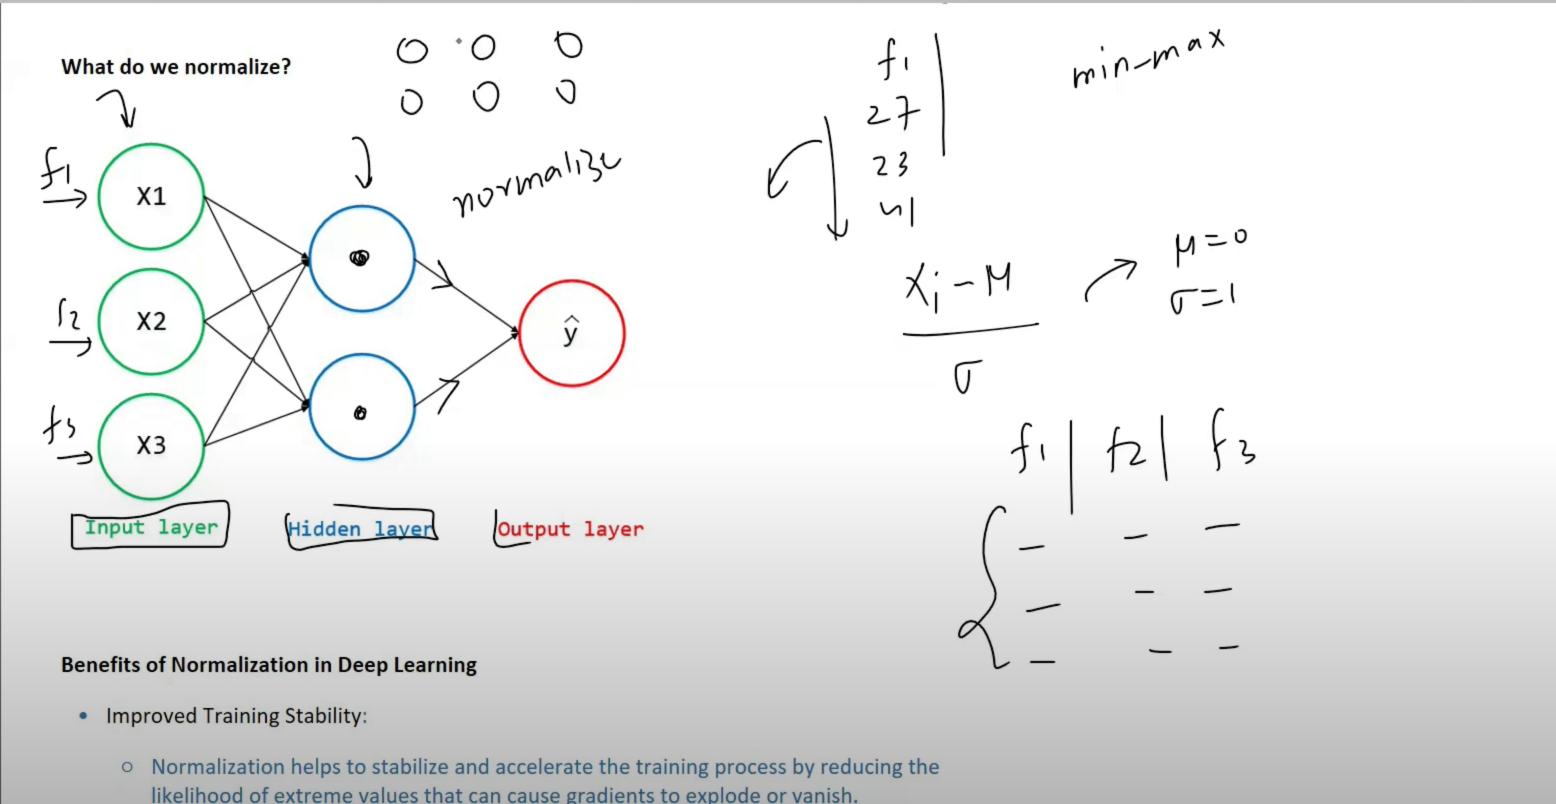

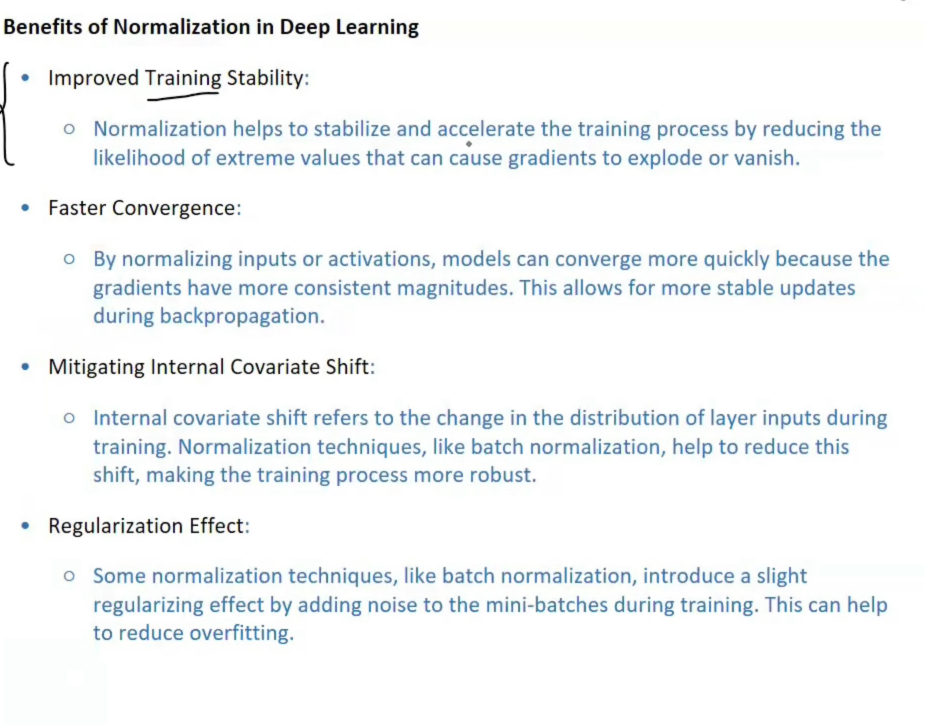

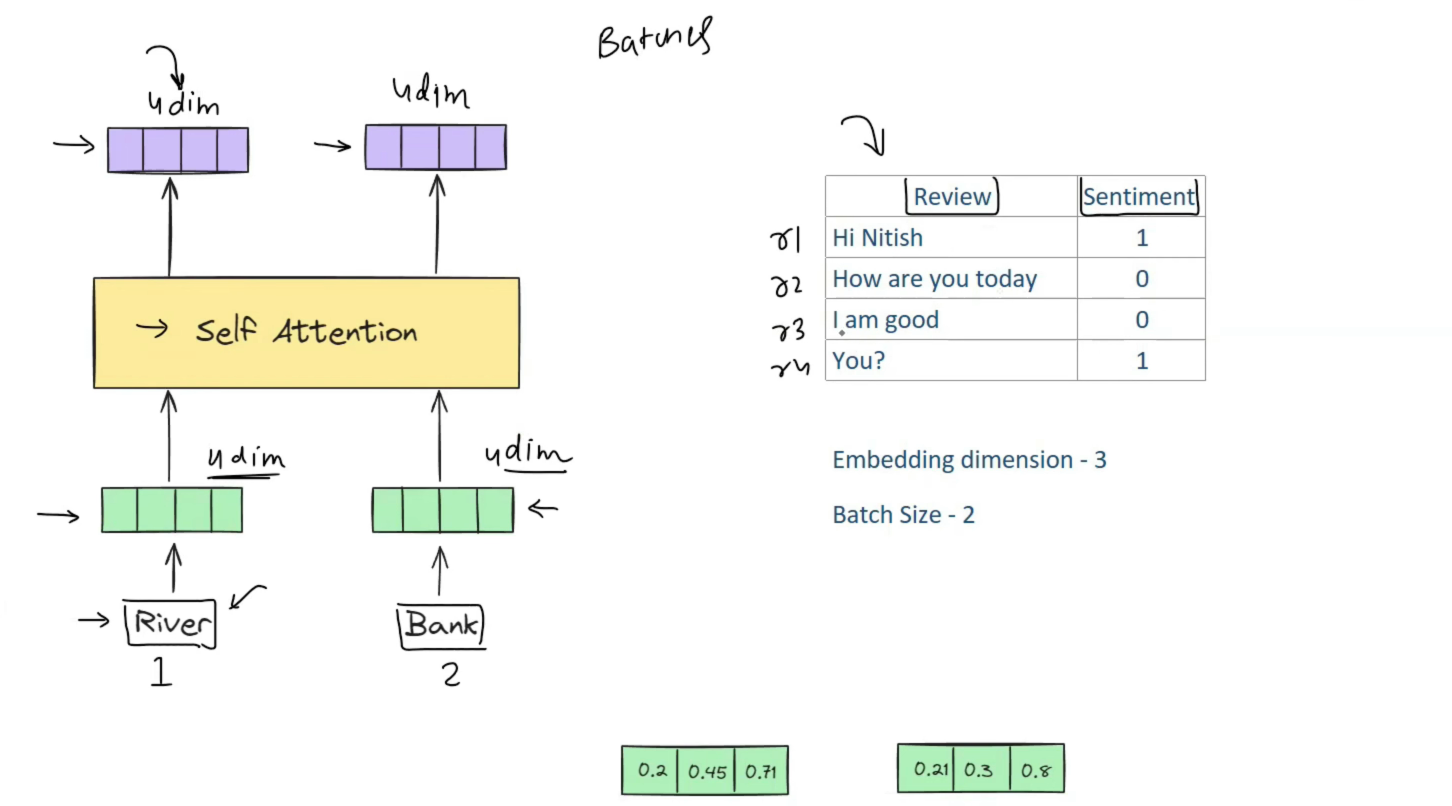

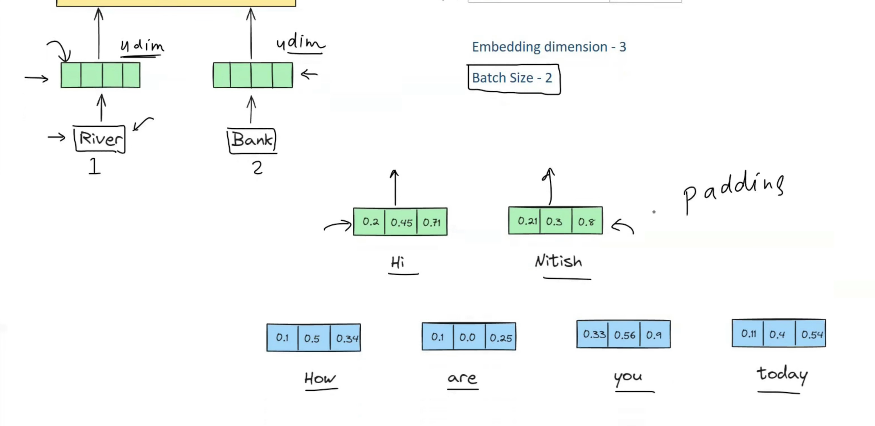

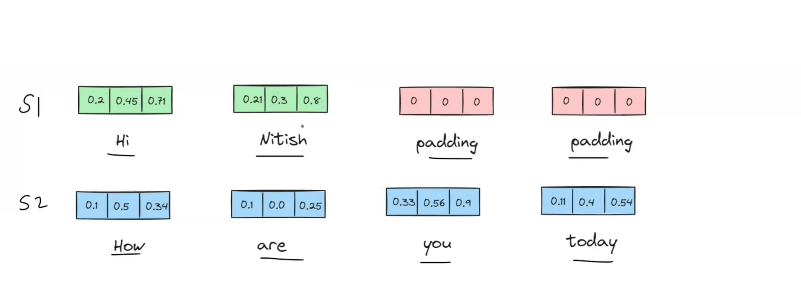

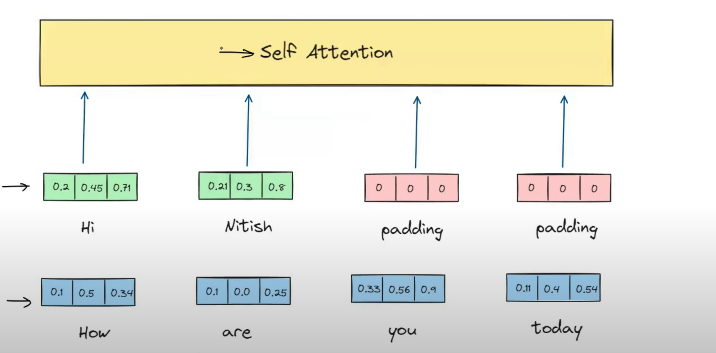

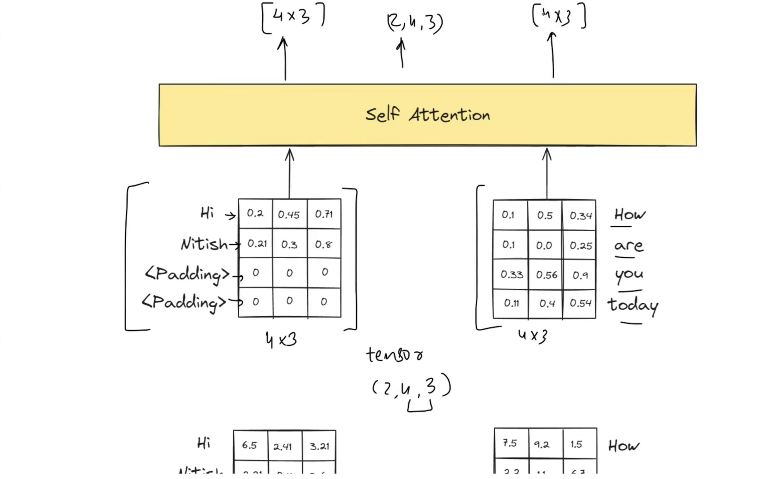

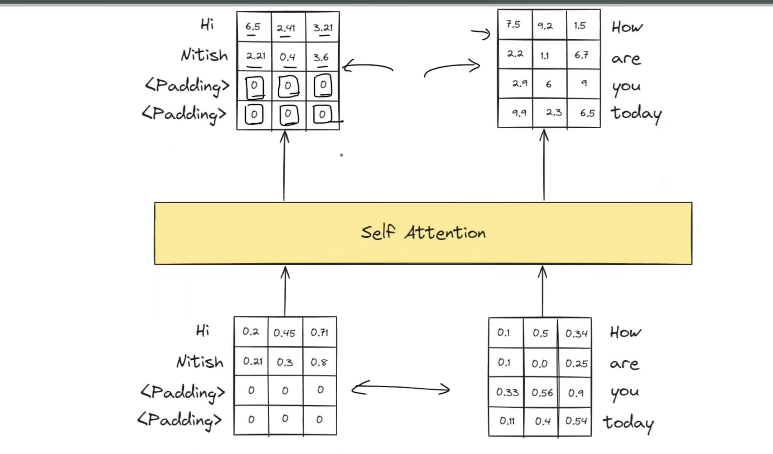

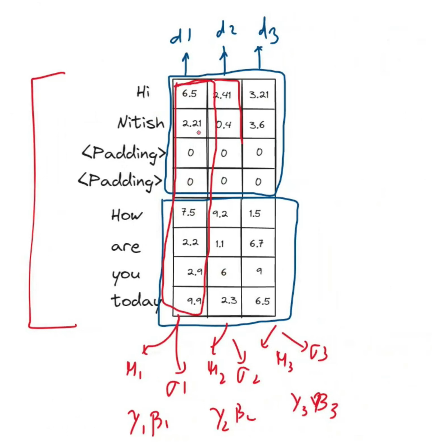

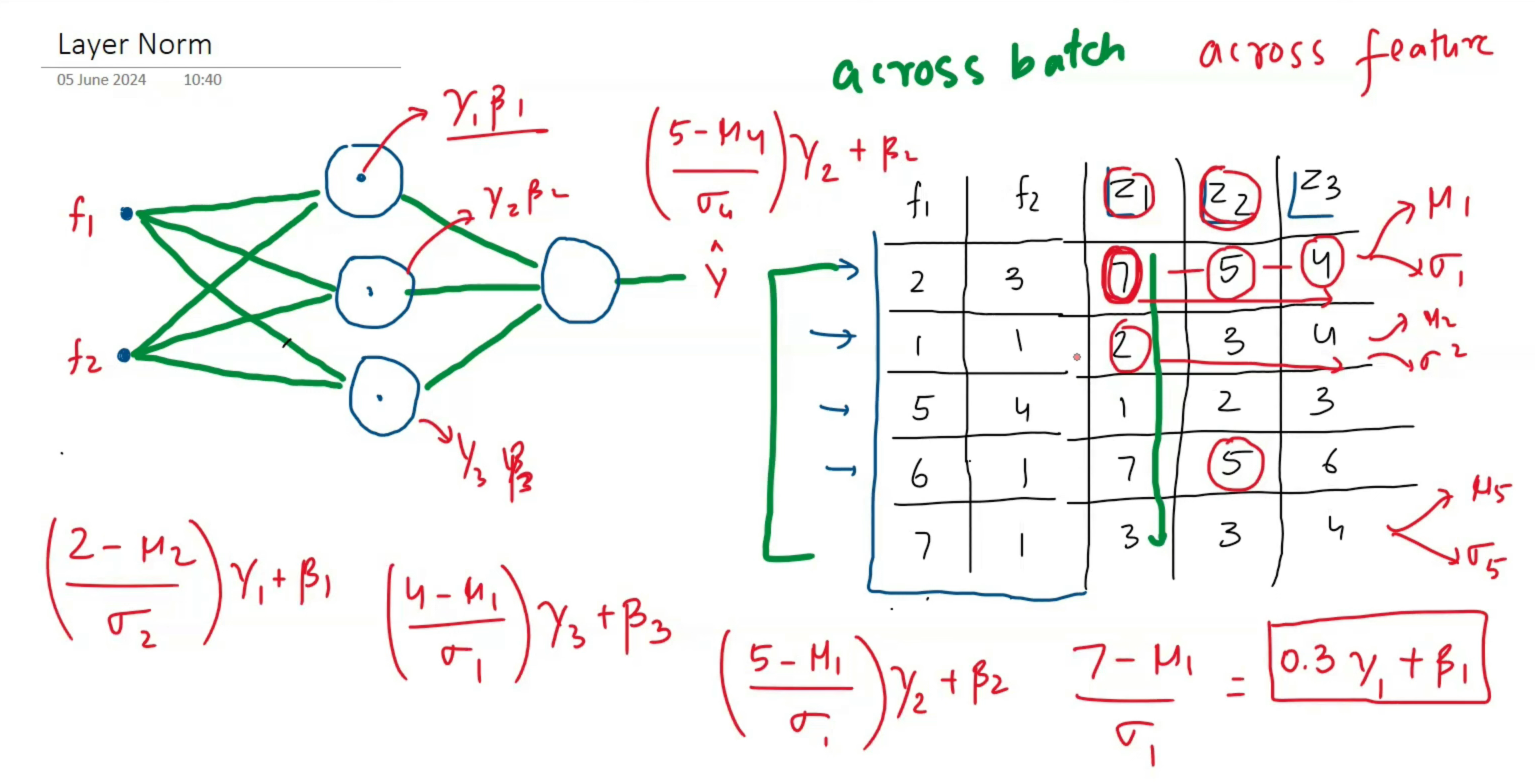

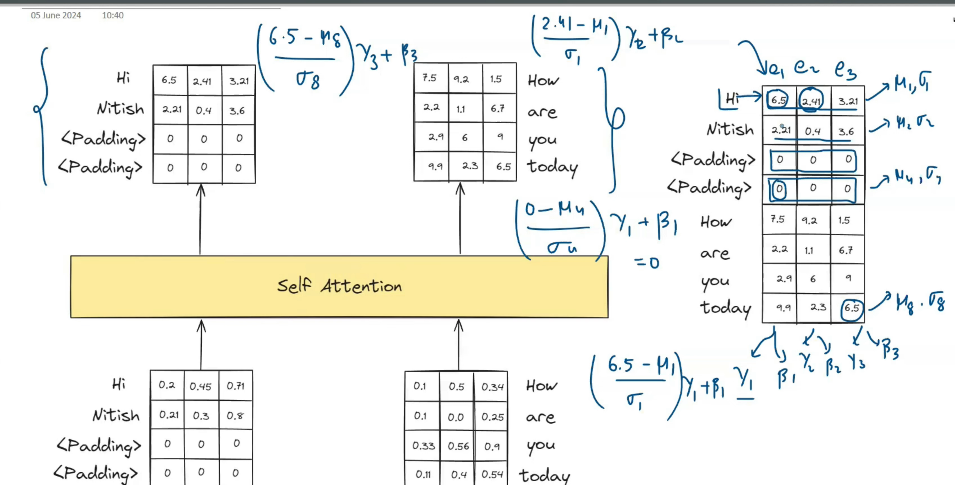

Normalization is a **fundamental technique in deep learning** that aims to **stabilize and accelerate the training process of neural networks** by transforming data to have consistent statistical properties, typically a **mean of zero and a standard deviation of one**. This technique is applied to both **input data** and the **activations of hidden layers**.

The core benefits of normalization include:
*   **Improved Training Stability and Faster Convergence:** It reduces the likelihood of extreme values in gradients, preventing issues like exploding or vanishing gradients, which makes backpropagation more stable and allows models to converge more quickly, often with higher learning rates.
*   **Mitigation of Internal Covariate Shift:** This refers to the problem where the distribution of hidden layer activations changes during training due to continuous updates of network weights. Normalization helps maintain consistent distributions, providing a more stable environment for subsequent layers to learn effectively and reducing training instability.
*   **Regularization Effect:** Some normalization methods, such as Batch Normalization, can introduce a slight random noise (due to batch-dependent statistics) that provides a minor regularization effect, which can help in reducing overfitting.
*   **Reduced Importance of Weight Initialization:** Normalization makes the training process less sensitive to the initial values of network weights, as it standardizes activations regardless of initial weight choices.

### Batch Normalization (BN): The General Approach and Its Limitations for Transformers

**How Batch Normalization Works:**
Batch Normalization processes data in "batches". For each feature (or the pre-activation of a neuron) in a hidden layer, it calculates the **mean ($\mu$) and standard deviation ($\sigma$) *across all data points within that specific batch***. These batch-specific statistics are then used to standardize the values for that feature.

The steps for a given neuron's pre-activation `z` within a batch are:
1.  **Calculate Batch Mean:** Compute the mean of `z` values across all examples in the current batch.
2.  **Calculate Batch Standard Deviation:** Compute the standard deviation of `z` values across all examples in the current batch.
3.  **Normalize:** Standardize each `z` value using the calculated batch mean and standard deviation: `z_normalized = (z - μ_batch) / σ_batch`. A small epsilon ( `ε` ) is often added to the denominator to prevent division by zero.
4.  **Scale and Shift:** Apply a learnable scaling factor, **gamma ($\gamma$)**, and a learnable shifting factor, **beta ($\beta$)**, to the normalized values: `output = γ * z_normalized + β`. These `γ` and `β` parameters are unique to each neuron (or feature dimension) and allow the network to adjust or "undo" the normalization if it determines a different distribution is more optimal for learning.

**Why Batch Normalization is Problematic for Transformers:**
While highly effective in many deep learning architectures, Batch Normalization is **not well-suited for Transformer architectures or sequential data** due to its interaction with variable sequence lengths and padding. Transformers frequently process sequences (e.g., sentences) of different lengths within a single batch. To handle this, shorter sequences are typically "padded" with zero vectors to match the length of the longest sequence in the batch.

The problem arises because when Batch Normalization calculates the mean and standard deviation for a given feature *across the batch's data points* (i.e., column-wise in a matrix of activations), these padded zero values are included in the calculation. If a batch contains many shorter sequences, the numerous zero-padding values will significantly **skew the calculated batch mean and standard deviation**, as these zeros do not represent actual data. This distortion renders the normalization ineffective and can harm model performance, making it unsuitable for the self-attention mechanism central to Transformers.

### Layer Normalization (LN): The Solution for Transformers and Its Steps

**How Layer Normalization Works (Steps):**
Layer Normalization provides an alternative that effectively addresses the issues BN faces with sequential data. Instead of normalizing across the batch, LN normalizes **across the features (or dimensions) *within each individual data point or sequence element***.

The steps for Layer Normalization for a given data point (e.g., a word embedding vector or a row of pre-activations `z_1, z_2, ..., z_k` from a layer):
1.  **Calculate Element-wise Mean:** For *each individual data point* (e.g., a single row of pre-activations), calculate the mean ($\mu$) *across all its features or dimensions*. If a layer has nodes with pre-activations `z1, z2, z3` for a single data point, the mean `μ` is calculated from these `z1, z2, z3` values.
2.  **Calculate Element-wise Standard Deviation:** For the *same individual data point*, calculate the standard deviation ($\sigma$) *across all its features or dimensions*.
3.  **Normalize Each Feature:** For each feature value `z_i` within that data point, normalize it using the element-wise mean and standard deviation: `z_normalized_i = (z_i - μ_element) / σ_element`.
4.  **Scale and Shift Each Feature:** Apply learnable scaling ($\gamma_i$) and shifting ($\beta_i$) parameters. Importantly, these `γ_i` and `β_i` parameters are **unique to each feature or dimension `i`**. The final normalized value for each feature `z_i` is then: `output_i = γ_i * z_normalized_i + β_i`.
    *   For example, if a data point has features `z1, z2, z3`, and their mean and std dev are `μ_row` and `σ_row` respectively:
        *   `output_1 = γ_1 * ((z1 - μ_row) / σ_row) + β_1`
        *   `output_2 = γ_2 * ((z2 - μ_row) / σ_row) + β_2`
        *   `output_3 = γ_3 * ((z3 - μ_row) / σ_row) + β_3`

**Why Layer Normalization is Preferred in Transformers:**
Layer Normalization is the **preferred choice for Transformers because its "across-feature" normalization directly solves the padding problem** that plagues Batch Normalization. When LN calculates statistics (mean and standard deviation) for a single word's embedding, it does so *across the dimensions of that specific word's embedding only*. The padded zero vectors in other words or sentences within the batch have **no impact whatsoever** on the normalization of that particular word's actual, non-zero embedding. Each real word's embedding is normalized based solely on its own intrinsic feature distribution, providing a true and meaningful normalization regardless of any padding present elsewhere in the input batch. Padded zeros, being zero, will normalize to zero, affecting only themselves, which is the desired behavior for masked inputs. This makes Layer Normalization perfectly suited for variable-length sequences and the self-attention mechanism central to Transformer architectures.

Normalization is a key technique in deep learning that transforms data to have specific statistical properties, such as a mean of zero and a standard deviation of one. This process is crucial for stabilizing and accelerating the training of neural networks.

Here's an in-depth look at its important aspects, why we use it, and the different approaches, especially in the context of Transformers:

**1. The "What" and "Why" of Normalization in Deep Learning**

*   **What is Normalized?** In deep learning, normalization is applied to two main areas:
    *   **Input data:** The features provided to the neural network.
    *   **Hidden layer activations:** The outputs generated by the neurons in the hidden layers before they pass through the activation function.
*   **Why is it Useful?** Normalization offers several significant benefits for training deep neural networks:
    *   **Improved Training Stability:** It reduces the likelihood of extreme values in gradients, preventing them from exploding or vanishing, which helps stabilize the backpropagation process. Keeping inputs and activations within a given range ensures more stable training.
    *   **Faster Convergence:** By normalizing inputs or activations, models can converge more quickly because gradients have more consistent magnitudes, leading to more efficient weight updates.
    *   **Mitigation of Internal Covariate Shift:** This is a major problem where the distribution of hidden layer activations changes over time during training due to the continuous update of network weights. Normalization helps to keep these distributions consistent, thereby allowing subsequent layers to learn more effectively.
    *   **Regularization Effect:** Some forms of normalization, like Batch Normalization, can also provide a slight regularization effect, which helps prevent overfitting.

**2. Batch Normalization: A Traditional Approach and Its Limitations**

*   **How it Works (The "What We Do"):** Batch Normalization (BN) processes data in "batches". For each feature (or node's pre-activation) in a hidden layer, it calculates the **mean and standard deviation *across all the data points within that batch***. Each number is then standardized using these batch-specific statistics. Finally, a "scaling and shifting" operation is applied using learnable parameters (gamma and beta) unique to each node, allowing the network to undo the normalization if needed.
*   **"What Other Way" (Why it's Problematic for Transformers):** While effective for many neural networks, Batch Normalization is **not well-suited for Transformer architectures or sequential data** due to how it interacts with self-attention.
    *   **The Padding Problem:** Transformers often process sentences of varying lengths in batches. To handle this, shorter sentences are "padded" with zero vectors to match the length of the longest sentence in the batch.
    *   **Skewed Statistics:** When Batch Normalization calculates the mean and standard deviation for a given feature *across the batch's data points* (i.e., down a column of embedding dimensions), these padded zero values are included in the calculation. If a batch contains many shorter sentences, the zero-padding significantly increases the number of zeros, leading to a **skewed mean and standard deviation** that do not truly represent the actual, non-padded data. This makes the normalization ineffective and can harm model performance.

**3. Layer Normalization: The Solution for Transformers**

*   **How it Works (The "What We Do"):** Layer Normalization (LN) offers a different approach. Instead of normalizing across the batch, it normalizes **across the features (or dimensions) *within each individual data point or sequence element***. For example, in a Transformer, for each word's embedding vector, LN calculates the mean and standard deviation *across all the dimensions of that specific word's embedding*. Then, it normalizes the values of that embedding vector using these statistics. Like BN, LN also applies learnable scaling (gamma) and shifting (beta) parameters, but these are applied per feature dimension rather than per node.
*   **"Why" it is Preferred in Transformers:** Layer Normalization directly solves the padding problem inherent in sequential data:
    *   Since the mean and standard deviation are calculated **per word (across its embedding dimensions)**, the padded zero vectors in other words or sentences have **no impact** on the normalization of actual, non-zero word embeddings.
    *   Each real word's embedding is normalized based solely on its own intrinsic feature distribution, providing a true and meaningful normalization, regardless of padding in other parts of the input batch. Padded zeros, being zero, will normalize to zero and will only affect themselves, which is the desired behavior.

In summary, while normalization is vital for deep learning training stability and convergence, **Layer Normalization is the preferred choice for Transformers because its "across-feature" normalization prevents the padding issue from distorting statistical calculations, ensuring effective normalization for sequential data**.

Normalization is a **fundamental technique in deep learning** that transforms data to have specific statistical properties, typically a **mean of zero and a standard deviation of one**. This process is applied to both **input data** and **hidden layer activations**. Its primary purpose is to **stabilize and accelerate the training of neural networks**.

The "why" behind normalization is multifaceted:
*   **Improved Training Stability and Faster Convergence**: By keeping inputs and activations within a controlled range, normalization prevents extreme values in gradients, which in turn reduces the likelihood of gradients exploding or vanishing. This makes the backpropagation process more stable and allows models to converge more quickly with higher learning rates.
*   **Mitigation of Internal Covariate Shift (ICS)**: A significant problem in deep learning is that the distribution of hidden layer activations can change over time as network weights are updated during training. This constant shift makes it harder for subsequent layers to learn effectively. Normalization, by ensuring consistent distributions (e.g., mean zero, std dev one), **reduces ICS**, providing a more stable "ground" for layers to learn.
*   **Regularization Effect**: Some forms of normalization, like Batch Normalization, can introduce a slight randomness due to batch-dependent statistics, which provides a minor regularization effect, helping to prevent overfitting.
*   **Reduced Importance of Weight Initialization**: Normalization can make the training process less sensitive to the initial values of network weights, as it standardizes activations regardless of initial weight choices.

### Batch Normalization (BN): The General Approach and Its Limitations

**What we do:** Batch Normalization works by processing data in "batches". For each feature (or neuron's pre-activation) in a hidden layer, it calculates the **mean and standard deviation *across all data points within that specific batch***. These batch-specific statistics are used to standardize the values. Subsequently, a **learnable "scaling and shifting" operation** is applied using two parameters, **gamma ($\gamma$) and beta ($\beta$)**, unique to each neuron. This allows the network the flexibility to undo or adjust the normalization if a different distribution proves more optimal.

**Why it's problematic for Transformers ("What other way"):** While highly effective for many neural networks, Batch Normalization is **not well-suited for Transformer architectures or sequential data** due to its interaction with variable sequence lengths and padding. Transformers often process sequences of different lengths within a batch, and shorter sequences are "padded" with zero vectors to match the longest sequence.
When Batch Normalization calculates statistics (mean and standard deviation) for a feature *across the batch's data points* (i.e., column-wise), these padded zero values are included. If a batch contains many shorter sequences, the numerous zero-padding values will significantly **skew the calculated mean and standard deviation**, as they do not represent actual data. This distortion renders the normalization ineffective for meaningful learning in sequential contexts like self-attention.

### Layer Normalization (LN): The Solution for Transformers

**What we do:** Layer Normalization offers an alternative approach that specifically addresses the issues BN faces with sequential data. Instead of normalizing across the batch, LN normalizes **across the features (or dimensions) *within each individual data point or sequence element***. For instance, in a Transformer, for each word's embedding vector, LN calculates the mean and standard deviation *across all the dimensions of that specific word's embedding*. These per-element statistics are then used to normalize the values of that embedding vector. Like BN, LN also applies **learnable scaling ($\gamma$) and shifting ($\beta$) parameters**, but these are associated with the embedding dimensions rather than across batch neurons.

**Why it is preferred in Transformers (The "Best Shot"):** Layer Normalization is the **preferred choice for Transformers because its "across-feature" normalization directly solves the padding problem**. When LN calculates statistics for a single word's embedding, the padded zero vectors in other words or sentences within the batch have **no impact** on the normalization of that particular word's actual, non-zero embedding. Each real word's embedding is normalized based solely on its own intrinsic feature distribution. Padded zeros, being zero, will normalize to zero, affecting only themselves, which is the desired behavior for masked inputs. This makes Layer Normalization perfectly suited for variable-length sequences and the self-attention mechanism central to Transformer architectures.


---

## 1. **What is LayerNorm?**

* **Definition:** Layer Normalization normalizes the summed inputs to a neuron **across the features of a single data sample**, rather than across the batch.

* **Formula (simplified):**
  For a vector of activations $x \in \mathbb{R}^d$,

  $$
  \hat{x}_i = \frac{x_i - \mu}{\sigma + \epsilon}, \quad \mu = \frac{1}{d}\sum_{j=1}^d x_j, \quad \sigma^2 = \frac{1}{d}\sum_{j=1}^d (x_j - \mu)^2
  $$

  Then scale and shift with learnable parameters $\gamma, \beta$.

* **Where it acts:** On each **sample independently**, across **features**.

* **Intuition:** Imagine each input example having its own "statistical context." LayerNorm makes sure the neuron activations within that example are balanced, without depending on other samples in the batch.

---

## 2. **Why not BatchNorm always?**

Batch Normalization was extremely popular (especially in CNNs), but it has **limitations**:

* **Batch dependence**:

  * BatchNorm computes mean & variance **across the batch dimension**.
  * This makes training unstable with small batch sizes (variance estimates are noisy).
  * Doesn’t work well when batch size = 1 (e.g., in RNNs or online inference).

* **Sequential models (RNNs, Transformers)**:

  * Different time steps in RNNs make batch statistics messy.
  * For Transformers, inputs are sequences — normalizing across batch dims can break consistency.

* **Inference mismatch**:

  * During training, stats are computed from the batch.
  * During inference, fixed “running averages” are used → possible mismatch if distribution shifts.

---

## 3. **Why LayerNorm helps**

* **Independent of batch size** → works with batch size = 1.
* **Works well in Transformers, RNNs, and sequence models** where the batch dimension doesn’t have nice statistical meaning.
* **Consistent at inference** → no need for moving averages.
* Stabilizes gradients by keeping activations normalized across features per sample.

---

## 4. **Other Normalization Methods (with intuition)**

* **Instance Normalization (InstanceNorm):**

  * Normalizes across spatial dimensions for each feature map of each sample (common in style transfer).
  * Intuition: Make each image’s feature maps independent of contrast/lighting.

* **Group Normalization (GroupNorm):**

  * Splits channels into groups, normalizes within each group.
  * Trade-off between BatchNorm and LayerNorm.
  * Works well in CNNs when batch sizes are small.

* **RMSNorm (Root Mean Square Norm):**

  * Variant of LayerNorm that uses only variance (ignores mean).
  * Simpler, sometimes faster, often used in large language models.

* **Weight Normalization:**

  * Normalizes the weights of layers instead of activations.
  * Intuition: control parameter scaling directly.

* **Batch Renormalization / Switchable Norm / EvoNorm:**

  * Variants that adaptively combine multiple normalization techniques depending on data.

---

## 5. **Summary (Intuition Chart)**

| Method           | Normalizes Over | Good For                         | Problem Fixed            |
| ---------------- | --------------- | -------------------------------- | ------------------------ |
| **BatchNorm**    | Batch, features | CNNs, large batches              | Internal covariate shift |
| **LayerNorm**    | Features only   | RNNs, Transformers, NLP          | Batch-size dependence    |
| **InstanceNorm** | Spatial dims    | Style transfer, generative tasks | Style/contrast issues    |
| **GroupNorm**    | Groups of chans | CNNs, small batches              | Small-batch instability  |
| **RMSNorm**      | Variance only   | Transformers, LLMs               | Simplification + speed   |

---

👉 In practice:

* **CNNs** → BatchNorm / GroupNorm.
* **Transformers / NLP / LLMs** → LayerNorm or RMSNorm.
* **Style transfer** → InstanceNorm.

---


